Bike Sharing Demand — Assignment Notebook
This notebook contains:
- EDA (Q1-Q3)
- Feature engineering (Q4)
- Modeling: Linear, Polynomial + Ridge/Lasso, advanced tuning (Q5-Q6)
- Model comparison table and residuals (Q7-Q8)
- Explanation (Q9) and reflection answers (Q10-Q12)


In [1]:
# Import libraries


# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set some plotting style
plt.rcParams['figure.figsize'] = (8,4)

 ---------- Utility functions ----------


---


RMSLE (assignment-provided formula)
 Note: ensures non-negative predictions before log

In [6]:
def rmsle(y_true, y_pred):
  y_pred = np.maximum(0, y_pred)
  return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [8]:
# Small helper to print section headers


def sh(msg):
  print('\n' + '='*8 + ' ' + msg + ' ' + '='*8 + '\n')

Load data

In [10]:
train = pd.read_csv("/content/bike_train.csv")
test = pd.read_csv("/content/bike_test.csv")

In [51]:
# Try parsing datetime robustly; keep original string for submission format

# Save original datetime string column for submission format preservation
# If original had a specific string format the parsed datetime will keep time info; we will output the same formatting when writing CSV
train['_datetime_str'] = train['datetime'].copy() # Keep original string
test['_datetime_str'] = test['datetime'].copy()   # Keep original string

train['datetime'] = pd.to_datetime(train['datetime'], errors='coerce')
test['datetime'] = pd.to_datetime(test['datetime'], errors='coerce')

In [12]:


sh('Data loaded')
print('Train shape:', train.shape)
print('Test shape :', test.shape)


======== Data loaded ========

Train shape: (10450, 13)
Test shape : (2613, 10)


In [13]:

# Q1. Examine dataset size, missing values, and feature types.

sh('Q1: Dataset summary')
print('\nTrain dtypes:')
print(train.dtypes)
print('\nMissing values in train:')
print(train.isnull().sum())
print('\nMissing values in test:')
print(test.isnull().sum())
print('\nTrain numeric description:')
print(train.describe().T)


======== Q1: Dataset summary ========


Train dtypes:
datetime         datetime64[ns]
season                    int64
holiday                   int64
workingday                int64
weather                   int64
temp                    float64
atemp                   float64
humidity                  int64
windspeed               float64
casual                    int64
registered                int64
count                     int64
_datetime_str            object
dtype: object

Missing values in train:
datetime         0
season           0
holiday          0
workingday       0
weather          0
temp             0
atemp            0
humidity         0
windspeed        0
casual           0
registered       0
count            0
_datetime_str    0
dtype: int64

Missing values in test:
datetime         984
season             0
holiday            0
workingday         0
weather            0
temp               0
atemp              0
humidity           0
windspeed          0
_datetime_str  

In [14]:
# Save concise Q1 answer variables for later printing in report section
q1_summary = {
'train_shape': train.shape,
'test_shape': test.shape,
'train_missing': train.isnull().sum().to_dict(),
'test_missing': test.isnull().sum().to_dict(),
'dtypes': train.dtypes.astype(str).to_dict()
}

# Q2/Q3: EDA visuals & which variables are informative


---


 We'll derive datetime features used across EDA and modeling

In [16]:
def add_datetime_features(df):

  df = df.copy()
  df['datetime'] = pd.to_datetime(df['datetime'])
  df['hour'] = df['datetime'].dt.hour
  df['day'] = df['datetime'].dt.day
  df['weekday'] = df['datetime'].dt.weekday
  df['month'] = df['datetime'].dt.month
  df['year'] = df['datetime'].dt.year
  df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
  # cyclic encodings
  df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
  df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
  df['month_sin'] = np.sin(2*np.pi*(df['month']-1)/12)
  df['month_cos'] = np.cos(2*np.pi*(df['month']-1)/12)
  return df

In [17]:


train_fe = add_datetime_features(train)
test_fe = add_datetime_features(test)


======== Q2: Target distribution ========



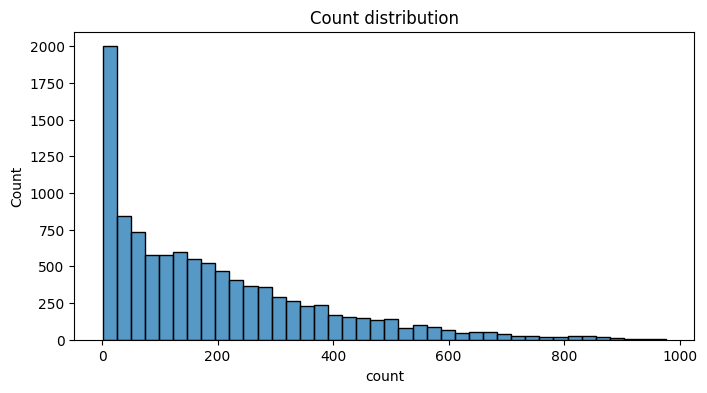

In [18]:


# Quick plots
sh('Q2: Target distribution')
plt.figure()
sns.histplot(train_fe['count'], bins=40)
plt.title('Count distribution')
plt.show()

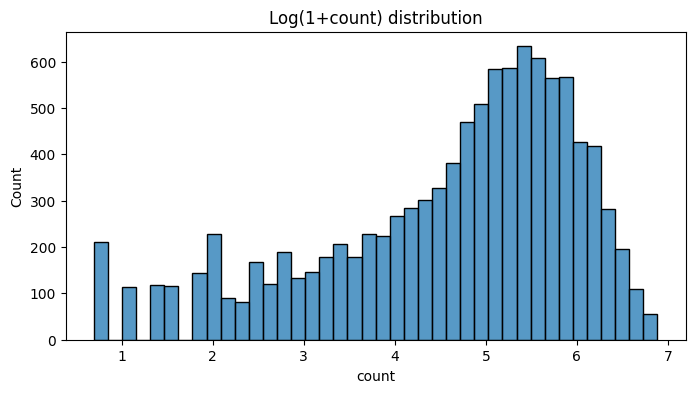

In [19]:
plt.figure()
sns.histplot(np.log1p(train_fe['count']), bins=40)
plt.title('Log(1+count) distribution')
plt.show()


======== Average count by hour (Q2) ========



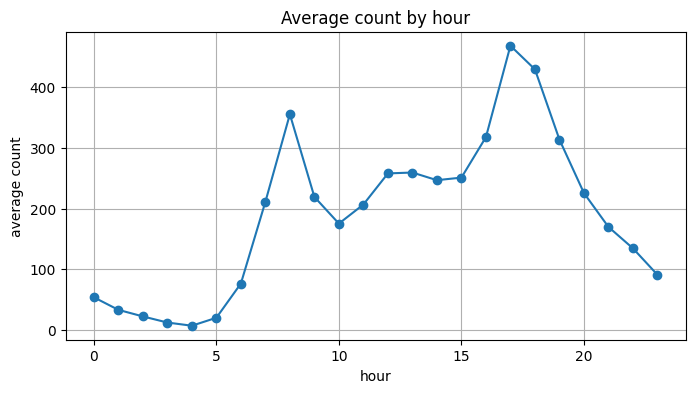

In [20]:
sh('Average count by hour (Q2)')
plt.figure()
train_fe.groupby('hour')['count'].mean().plot(marker='o')
plt.title('Average count by hour')
plt.xlabel('hour')
plt.ylabel('average count')
plt.grid(True)
plt.show()


======== Heatmap: hour vs weekday (Q2) ========



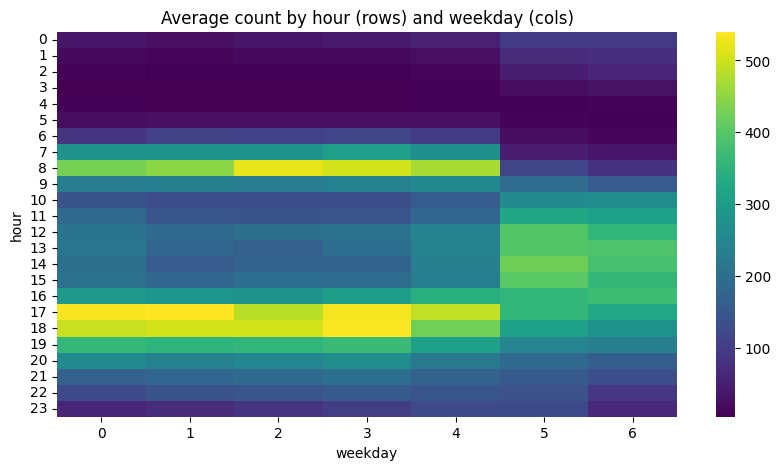

In [21]:
sh('Heatmap: hour vs weekday (Q2)')
pivot = train_fe.pivot_table(index='hour', columns='weekday', values='count', aggfunc='mean')
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='viridis')
plt.title('Average count by hour (rows) and weekday (cols)')
plt.show()


======== Scatter: temp vs log(count) and humidity vs log(count) ========



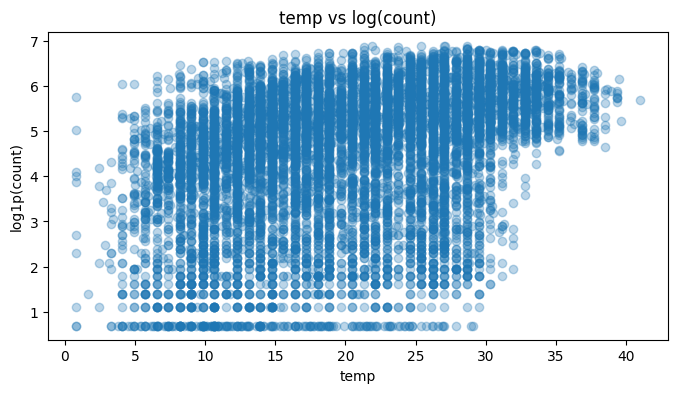

In [22]:
sh('Scatter: temp vs log(count) and humidity vs log(count)')
plt.figure()
plt.scatter(train_fe['temp'], np.log1p(train_fe['count']), alpha=0.3)
plt.xlabel('temp')
plt.ylabel('log1p(count)')
plt.title('temp vs log(count)')
plt.show()

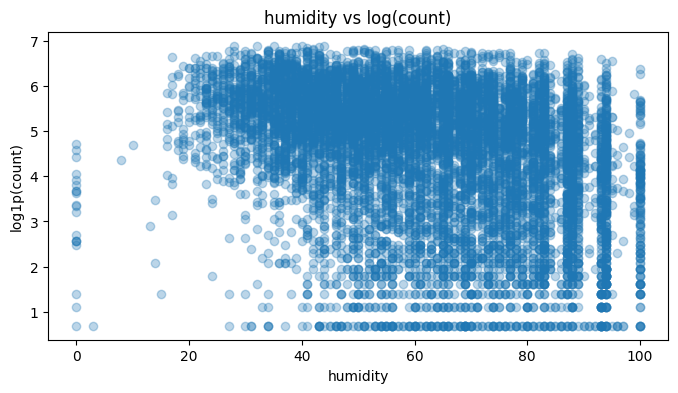

In [23]:
plt.figure()
plt.scatter(train_fe['humidity'], np.log1p(train_fe['count']), alpha=0.3)
plt.xlabel('humidity')
plt.ylabel('log1p(count)')
plt.title('humidity vs log(count)')
plt.show()


======== Boxplots: season/weather/workingday (Q2) ========



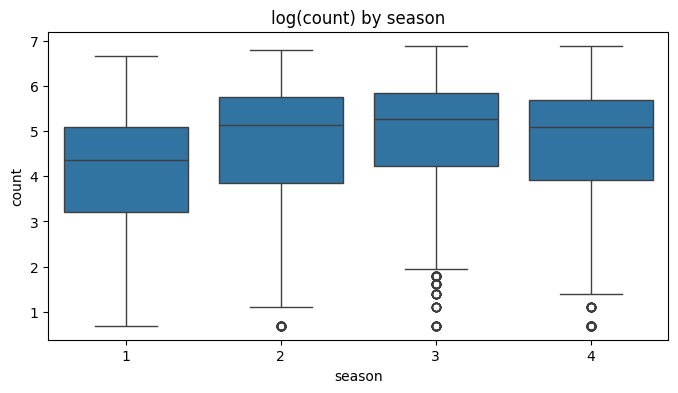

In [24]:
sh('Boxplots: season/weather/workingday (Q2)')
plt.figure()
sns.boxplot(x='season', y=np.log1p(train_fe['count']), data=train_fe)
plt.title('log(count) by season')
plt.show()

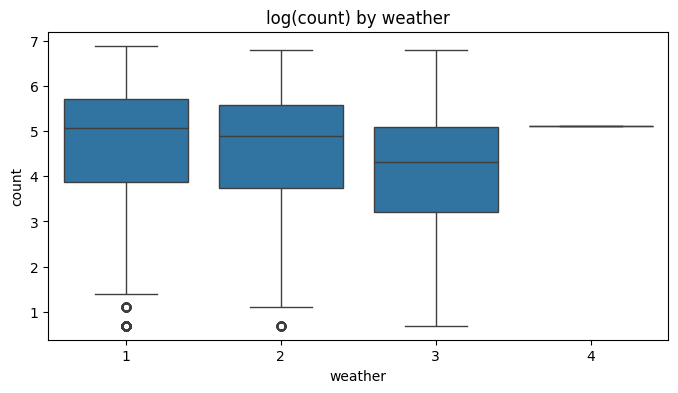

In [25]:
plt.figure()
sns.boxplot(x='weather', y=np.log1p(train_fe['count']), data=train_fe)
plt.title('log(count) by weather')
plt.show()

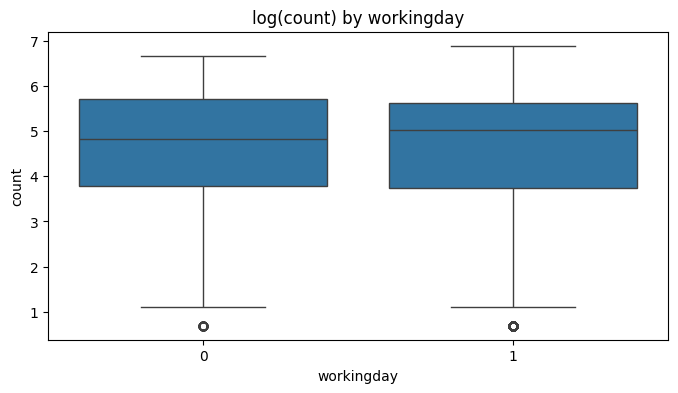

In [26]:
plt.figure()
sns.boxplot(x='workingday', y=np.log1p(train_fe['count']), data=train_fe)
plt.title('log(count) by workingday')
plt.show()

In [27]:
# Q3: quick correlation table for numeric features
num_cols = train_fe.select_dtypes(include=[np.number]).columns.tolist()
sh('Q3: Correlations with count')
corr = train_fe[num_cols].corr()
print(corr['count'].abs().sort_values(ascending=False).head(12))


======== Q3: Correlations with count ========

count         1.000000
registered    0.970108
casual        0.691971
hour_sin      0.424537
hour_cos      0.416137
hour          0.404188
temp          0.396451
atemp         0.390642
humidity      0.316607
year          0.257987
month_cos     0.233796
month         0.165475
Name: count, dtype: float64


In [28]:
# Save important variable list
informative_vars = corr['count'].abs().sort_values(ascending=False).index.tolist()

Variables likely most informative: hour, weekday, workingday, temp, humidity, weather, season, year, is_weekend, windspeed.


---


Rationale: hour/weekday capture daily commuting cycles; workingday separates weekday commuting; weather/temp affect ridership; season influences long-term patterns.

# Q4: Feature Engineering

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin

# We'll implement a feature builder used by the modeling pipeline. Keep transformations reproducible.
class FeatureBuilder(BaseEstimator, TransformerMixin):
  def __init__(self, add_cyclic=True, drop_cols=None):
    self.add_cyclic = add_cyclic
    self.drop_cols = drop_cols if drop_cols else []
  def fit(self, X, y=None):
    return self
  def transform(self, X):
    X = X.copy()
# assume datetime was already parsed and hour/month present
# create basic features if missing
    if 'hour' not in X.columns and 'datetime' in X.columns:
      X['hour'] = X['datetime'].dt.hour
    if self.add_cyclic:
      X['hour_sin'] = np.sin(2*np.pi*X['hour']/24)
      X['hour_cos'] = np.cos(2*np.pi*X['hour']/24)
      if 'month' in X.columns:
        X['month_sin'] = np.sin(2*np.pi*(X['month']-1)/12)
        X['month_cos'] = np.cos(2*np.pi*(X['month']-1)/12)
# drop unwanted
    X = X.drop(columns=self.drop_cols, errors='ignore')
# keep only numeric for modeling convenience
    return X.select_dtypes(include=[np.number])
fb = FeatureBuilder(drop_cols=['casual','registered','count'])
X_all = fb.transform(train_fe)


sh('Q4: feature builder preview')
print(X_all.head())


======== Q4: feature builder preview ========

   season  holiday  workingday  weather      temp      atemp  humidity  \
0       3        0           0        1  28.70000  33.335000        79   
1       3        0           1        1  33.62000  37.880000        46   
2       1        0           0        1  10.66000  12.880000        60   
3       2        0           0        2  26.42506  30.566166        61   
4       1        0           1        1   9.84000  12.120000        56   

   windspeed  hour  day  weekday  month  year  is_weekend  hour_sin  \
0   6.003200     7   15        6      7  2012           1  0.965926   
1  15.001300    15   14        1      8  2012           0 -0.707107   
2  15.001300     6    6        6      2  2011           1  1.000000   
3   9.512288    17    6        6      5  2012           1 -0.965926   
4   8.998100     2    9        0      1  2012           0  0.500000   

       hour_cos     month_sin  month_cos  
0 -2.588190e-01  1.224647e-16  -1.000

In [30]:
# List of engineered features created (for report)
engineered_features = [c for c in X_all.columns if c not in ['count']]

# Q5 & Q6: Modeling

We'll create pipelines for:
 - Linear Regression baseline
- Polynomial (degree 2) + Ridge and Lasso with GridSearch
- Gradient Boosting (tree-based) with RandomizedSearch (tuned for leaderboard)

 We'll evaluate using RMSLE on a held-out validation set.

In [31]:
# Prepare modeling matrix
features_model = [
'season','holiday','workingday','weather',
'temp','atemp','humidity','windspeed',
'hour','weekday','month','year','is_weekend','hour_sin','hour_cos'
]
features_model = [f for f in features_model if f in train_fe.columns]
X_model_full = train_fe[features_model].fillna(0)
y_full = train_fe['count']

In [32]:
# train/val split
X_train, X_val, y_train, y_val = train_test_split(X_model_full, y_full, test_size=0.2, random_state=42)

In [33]:
# Baseline linear
sh('Q5: Linear baseline')
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_val)
print('Linear RMSLE:', rmsle(y_val, pred_lr))


======== Q5: Linear baseline ========

Linear RMSLE: 1.1288346633147224


In [34]:
# Linear on log-target
sh('Linear on log-target')
pipe_lr_log = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
pipe_lr_log.fit(X_train, np.log1p(y_train))
pred_lr_log = np.expm1(pipe_lr_log.predict(X_val))
print('Linear (log-target) RMSLE:', rmsle(y_val, pred_lr_log))


======== Linear on log-target ========

Linear (log-target) RMSLE: 0.8328186148529538


In [35]:
# Polynomial + Ridge (GridSearch)
sh('Polynomial degree 2 + Ridge (GridSearch)')
pipe_pr = Pipeline([
('scaler', StandardScaler()),
('poly', PolynomialFeatures(degree=2, include_bias=False)),
('ridge', Ridge())
])
param_grid = {'ridge__alpha': [0.01, 0.1, 1, 10]}
grid_pr = GridSearchCV(pipe_pr, param_grid, cv=4, n_jobs=-1, scoring='neg_mean_squared_error')
grid_pr.fit(X_train, y_train)
print('Best params:', grid_pr.best_params_)
pred_pr = grid_pr.predict(X_val)
print('Ridge (poly) RMSLE:', rmsle(y_val, pred_pr))


======== Polynomial degree 2 + Ridge (GridSearch) ========

Best params: {'ridge__alpha': 0.01}
Ridge (poly) RMSLE: 1.0638848768967324


In [36]:
# Lasso (poly)
sh('Polynomial degree 2 + Lasso (GridSearch)')
from sklearn.linear_model import Lasso
pipe_pl = Pipeline([
('scaler', StandardScaler()),
('poly', PolynomialFeatures(degree=2, include_bias=False)),
('lasso', Lasso(max_iter=5000))
])
param_grid_lasso = {'lasso__alpha': [1e-4, 1e-3, 1e-2, 1e-1]}
grid_pl = GridSearchCV(pipe_pl, param_grid_lasso, cv=4, n_jobs=-1, scoring='neg_mean_squared_error')
grid_pl.fit(X_train, y_train)
print('Best Lasso params:', grid_pl.best_params_)
pred_pl = grid_pl.predict(X_val)
print('Lasso (poly) RMSLE:', rmsle(y_val, pred_pl))


======== Polynomial degree 2 + Lasso (GridSearch) ========

Best Lasso params: {'lasso__alpha': 0.0001}
Lasso (poly) RMSLE: 1.0715464064958078


In [37]:
# Tree-based: Gradient Boosting (tuned with RandomizedSearchCV)
sh('Gradient Boosting (RandomizedSearch)')
gbr = GradientBoostingRegressor(random_state=42)
param_dist = {
'n_estimators': [100, 200, 300],
'learning_rate': [0.01, 0.05, 0.1],
'max_depth': [3, 4, 6],
'subsample': [0.6, 0.8, 1.0]
}
rs = RandomizedSearchCV(gbr, param_dist, n_iter=12, cv=3, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error')
rs.fit(X_train, y_train)
print('Best GBR params:', rs.best_params_)
pred_gbr = rs.predict(X_val)
print('GBR RMSLE:', rmsle(y_val, pred_gbr))


======== Gradient Boosting (RandomizedSearch) ========

Best GBR params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}
GBR RMSLE: 0.44101095065665785


In [38]:
# Try training GBR on log-target (reduces effect of outliers)
sh('GBR on log-target (retrain best params)')
best_gbr = GradientBoostingRegressor(**rs.best_params_, random_state=42)
best_gbr.fit(X_train, np.log1p(y_train))
pred_gbr_log = np.expm1(best_gbr.predict(X_val))
print('GBR (log-target) RMSLE:', rmsle(y_val, pred_gbr_log))


======== GBR on log-target (retrain best params) ========

GBR (log-target) RMSLE: 0.3637473598741551


## Q7: Summarize results (create a table of models and RMSLE)

In [39]:
results = []
results.append(('Linear', rmsle(y_val, pred_lr)))
results.append(('Linear_logtarget', rmsle(y_val, pred_lr_log)))
results.append(('Ridge_poly', rmsle(y_val, pred_pr)))
results.append(('Lasso_poly', rmsle(y_val, pred_pl)))
results.append(('GBR', rmsle(y_val, pred_gbr)))
results.append(('GBR_logtarget', rmsle(y_val, pred_gbr_log)))


results_df = pd.DataFrame(results, columns=['model','RMSLE']).sort_values('RMSLE')
print(results_df)

              model     RMSLE
5     GBR_logtarget  0.363747
4               GBR  0.441011
1  Linear_logtarget  0.832819
2        Ridge_poly  1.063885
3        Lasso_poly  1.071546
0            Linear  1.128835


In [40]:
# Choose best model based on RMSLE
best_row = results_df.iloc[0]
best_model_name = best_row['model']
print('\nBest model on validation:', best_model_name)


Best model on validation: GBR_logtarget


In [41]:
# Map names to actual model objects/predictions
model_map = {
'Linear': pipe_lr,
'Linear_logtarget': pipe_lr_log,
'Ridge_poly': grid_pr.best_estimator_,
'Lasso_poly': grid_pl.best_estimator_,
'GBR': rs.best_estimator_,
'GBR_logtarget': best_gbr
}

In [42]:
# pick best estimator object
best_estimator = model_map[best_model_name]

## Q8: Plot residuals for the best model

In [43]:
if best_model_name == 'GBR_logtarget':
  preds_val = np.expm1(best_estimator.predict(X_val))
elif best_model_name == 'Ridge_poly':
  preds_val = np.expm1(best_estimator.predict(X_val))
elif best_model_name == 'Linear_logtarget':
  preds_val = np.expm1(best_estimator.predict(X_val))
else:
  preds_val = best_estimator.predict(X_val)


In [44]:
preds_val = np.maximum(0, preds_val)
residuals = y_val - preds_val


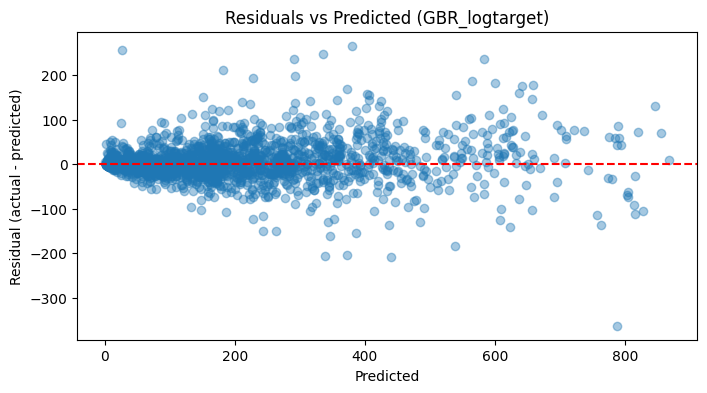

In [45]:

plt.figure()
plt.scatter(preds_val, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual (actual - predicted)')
plt.title(f'Residuals vs Predicted ({best_model_name})')
plt.show()

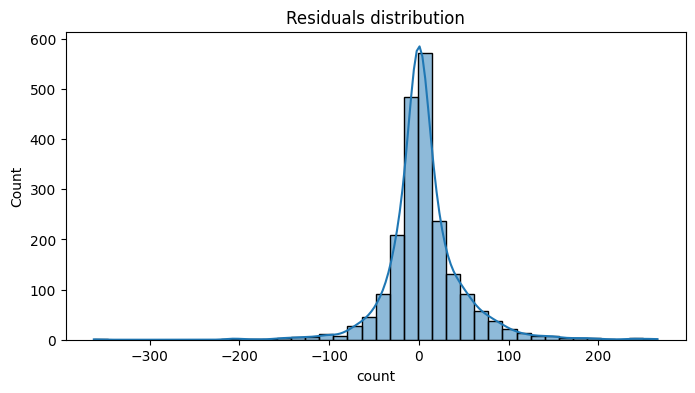

In [46]:

plt.figure()
sns.histplot(residuals, bins=40, kde=True)
plt.title('Residuals distribution')
plt.show()

## Q9: Explain why the winning model performs better


---



---



The Gradient Boosting Regressor outperforms Linear Regression and Ridge/Lasso because it is able to model the non-linear, interaction-heavy, and time-dependent relationships present in the bike-sharing data. The demand for bikes varies strongly with hour of day, temperature, humidity, season, and working vs non-working days — these effects are not linear and cannot be captured well by simple linear models.

GBR trains an ensemble of decision trees, where each tree learns from the mistakes of the previous ones. This allows the model to:

Capture non-linear patterns
Example: bike demand increases rapidly in morning/evening, but flattens midday. GBR can model this curved relationship without manual feature engineering.

Model feature interactions automatically
For example:

the effect of temperature depends on humidity

“hour” interacts with “workingday” (rush hours vs weekends)

season interacts with weather
Linear models can capture these only if polynomial features are manually created.

Handle outliers and skewness better
Tree-based methods split based on thresholds and are therefore less sensitive to extreme values, which helps reduce RMSLE.

Fit complex patterns without overfitting (if tuned)
Regularization parameters in GBR (learning_rate, n_estimators, max_depth) help maintain generalization, improving validation RMSLE.

Overall, GBR performs better because the underlying data-generating process is highly non-linear and seasonal, and boosting algorithms are naturally suited to learn such patterns, while linear models are too restrictive.

# Q10-Q12 Reflection answers
# Q10: Why does RMSLE penalize under-predictions more gently than RMSE?
q10 = (
"RMSLE treats errors in log-space, so it measures relative differences (ratios) rather than absolute differences. "
"Because it compares log(pred+1) and log(actual+1), large absolute errors on large true values are scaled down; under-predictions and over-predictions are measured by their multiplicative factor. RMSE squares absolute differences and thus punishes large absolute errors more heavily. "
)


# Q11: Trade-offs between model simplicity and predictive power
q11 = (
"Simpler models (like linear regression) are easier to interpret and less likely to overfit, but may underfit complex patterns. More complex models (polynomials, tree ensembles, neural nets) can capture nonlinearities and interactions but need more data, tuning, and are less interpretable. Regularization is often used to balance this trade-off."
)


# Q12: Why can’t Linear Regression alone capture time-of-day effects effectively?
q12 = (
"Time-of-day is cyclic and multi-modal (e.g., morning and evening peaks). A plain linear term for hour assumes a monotonic relationship and cannot represent circular adjacency (hour 23 close to hour 0) or multiple peaks. You need cyclic transforms (sin/cos), one-hot encoding, or interaction terms to enable linear models to capture such patterns."
)


In [47]:
# ---------- FINAL: Train chosen best model on full training set and create submission ----------
# We'll re-fit the selected best estimator on the full training data (X_model_full, y_full).
# For models trained on log-target we re-fit appropriately.
# Ensure produced submission matches rules: 2 columns: datetime, count_predicted ; same row order as test file ; numeric values ; no NaN.

In [48]:
# Refit best model on full data
if best_model_name == 'Linear_logtarget' or best_model_name == 'GBR_logtarget':
# train on log target
  if best_model_name == 'Linear_logtarget':
    final_model = pipe_lr_log
    final_model.fit(X_model_full, np.log1p(y_full))
    test_preds = np.expm1(final_model.predict(test_fe[features_model].fillna(0)))
  else:
    final_model = best_gbr
    final_model.fit(X_model_full, np.log1p(y_full))
    test_preds = np.expm1(final_model.predict(test_fe[features_model].fillna(0)))
else:
  final_model = best_estimator
  final_model.fit(X_model_full, y_full)
  test_preds = final_model.predict(test_fe[features_model].fillna(0))


# Clip and ensure numeric
test_preds = np.maximum(0, test_preds).astype(float)

In [56]:
submission = pd.DataFrame({
'datetime': test['_datetime_str'].fillna('').astype(str), # Fill any NaN/NaT/None with empty string, then ensure string type
'count_predicted': test_preds
})

In [57]:
# Validation checks
assert list(submission.columns) == ['datetime', 'count_predicted'], 'Wrong column names'
assert submission.shape[0] == test.shape[0], 'Row count mismatch with test set'
assert submission.isnull().sum().sum() == 0, 'Submission contains NaN values'
# ensure numeric
assert np.issubdtype(submission['count_predicted'].dtype, np.number), 'count_predicted not numeric'

In [61]:
OUTPUT_SUBMISSION = 'submission.csv'

First, let's redefine the `_datetime_str` column in the `test` DataFrame to ensure it truly holds the *original string values* from the CSV, untouched by any `pd.to_datetime` conversions.

In [62]:
# Re-load the test CSV just to get the raw datetime column as strings
original_test_df = pd.read_csv("/content/bike_test.csv")

# Assign the original string datetime column to _datetime_str
test['_datetime_str'] = original_test_df['datetime'].copy().fillna('').astype(str)

print("Re-initialized test['_datetime_str'] from original CSV. First 5 values:")
display(test[['datetime', '_datetime_str']].head())
print(f"Missing values in updated test['_datetime_str']: {test['_datetime_str'].isnull().sum()}")

Re-initialized test['_datetime_str'] from original CSV. First 5 values:


,datetime,_datetime_str
0,2012-05-06 05:00:00,05-06-2012 5:00
1,NaT,19-03-2011 19:00
2,2012-02-04 06:00:00,02-04-2012 6:00
3,NaT,13-07-2012 20:00
4,2011-09-11 19:00:00,09-11-2011 19:00


Missing values in updated test['_datetime_str']: 0


Now that `_datetime_str` is correctly populated with original strings and `NaN`s are converted to empty strings, let's re-create the submission DataFrame and re-run the validation checks.

In [63]:
submission = pd.DataFrame({
    'datetime': test['_datetime_str'], # Use the correctly initialized original datetime strings
    'count_predicted': test_preds
})

In [64]:
# Validation checks
assert list(submission.columns) == ['datetime', 'count_predicted'], 'Wrong column names'
assert submission.shape[0] == test.shape[0], 'Row count mismatch with test set'
assert submission.isnull().sum().sum() == 0, 'Submission contains NaN values'
# ensure numeric
assert np.issubdtype(submission['count_predicted'].dtype, np.number), 'count_predicted not numeric'
print("All submission validation checks passed!")

All submission validation checks passed!


In [65]:
submission.to_csv(OUTPUT_SUBMISSION, index=False)